# Yaw-Only Output Feedback for Fault Diagnosis

## Problem Formulation

This notebook demonstrates **yaw-only feedback control** where the controller has **NO access to position** (px, py), only yaw angle.

### System

**State (4D)**: `x = [px, py, yaw, omega]`
- `px, py`: Position (HIDDEN from controller!)
- `yaw`: Heading angle (OBSERVED)
- `omega`: Angular velocity (HIDDEN)

**Control (3D)**: `u = [vx, vy, u_omega]`

**Observation (scalar!)**: `y = yaw`

### Feedback Controller

```
u[t] = u_nom[t] + K[t] * (yaw[t] - yaw_nom[t])
```

where:
- `u_nom[t] ∈ ℝ³`: Nominal feedforward control
- `K[t] ∈ ℝ³`: **Yaw-to-control feedback gains** (optimized for fault separation)
- `(yaw[t] - yaw_nom[t]) ∈ ℝ`: Scalar yaw error

**Key challenge**: Without position feedback, the controller must infer position deviations from yaw alone!

### Optimization Objective

Find `K[t]` to:
1. **Maximize separation** between fault scenario reachable sets
2. **Track nominal trajectory** (stay close to feedforward)

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

from go2_yaw_only_feedback_controller import (
    YawOnlyFeedbackOptimizer,
    create_scenarios,
    Interval
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

np.random.seed(42)

print("✓ Libraries imported")

/home/user/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


✓ Libraries imported


## 1. Create Nominal Trajectory

Nominal trajectory:
  State: 4D [px, py, yaw, omega]
  Control: 3D [vx, vy, u_omega]
  Observation: 1D (yaw only!)
  Duration: 5.0s over 20 steps


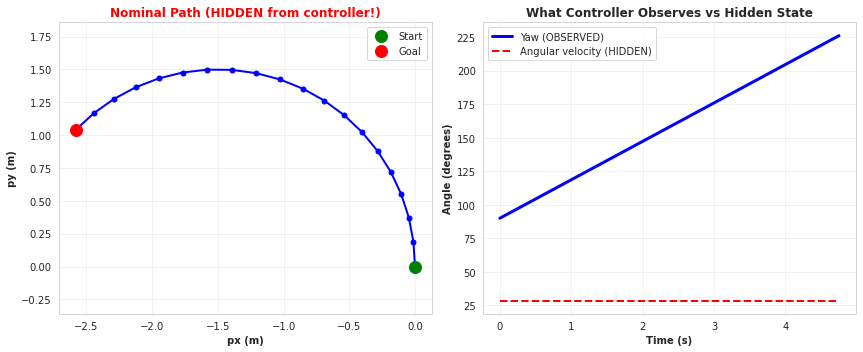

In [2]:
# Circular trajectory
N = 20
dt = 0.25
t = np.linspace(0, (N-1)*dt, N)

radius = 1.5
omega_nom = 0.5

px_nom = radius * np.cos(omega_nom * t) - radius
py_nom = radius * np.sin(omega_nom * t)
yaw_nom = omega_nom * t + np.pi/2
omega_state_nom = np.ones(N) * omega_nom

x_nom_traj = np.column_stack([px_nom, py_nom, yaw_nom, omega_state_nom])

vx_nom = -radius * omega_nom * np.sin(omega_nom * t)
vy_nom = radius * omega_nom * np.cos(omega_nom * t)
u_omega_nom = np.zeros(N)

u_nom_traj = np.column_stack([vx_nom, vy_nom, u_omega_nom])

print(f"Nominal trajectory:")
print(f"  State: 4D [px, py, yaw, omega]")
print(f"  Control: 3D [vx, vy, u_omega]")
print(f"  Observation: 1D (yaw only!)")
print(f"  Duration: {N*dt}s over {N} steps")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Position
axes[0].plot(px_nom, py_nom, 'b-o', linewidth=2, markersize=5)
axes[0].plot(px_nom[0], py_nom[0], 'go', markersize=12, label='Start')
axes[0].plot(px_nom[-1], py_nom[-1], 'ro', markersize=12, label='Goal')
axes[0].set_xlabel('px (m)', fontweight='bold')
axes[0].set_ylabel('py (m)', fontweight='bold')
axes[0].set_title('Nominal Path (HIDDEN from controller!)', fontweight='bold', color='red')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axis('equal')

# Yaw (what controller sees)
axes[1].plot(t, np.degrees(yaw_nom), 'b-', linewidth=3, label='Yaw (OBSERVED)')
axes[1].plot(t, np.degrees(omega_state_nom), 'r--', linewidth=2, label='Angular velocity (HIDDEN)')
axes[1].set_xlabel('Time (s)', fontweight='bold')
axes[1].set_ylabel('Angle (degrees)', fontweight='bold')
axes[1].set_title('What Controller Observes vs Hidden State', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Define Fault Scenarios

In [3]:
scenarios = create_scenarios()

print("Fault Scenarios:")
print("="*70)
for s in scenarios:
    print(f"\n{s.name}:")
    print(f"  Actuator effectiveness α: {s.alpha_range}")
    print(f"  Gyro scale factor a:      {s.gyro_scale_range}")
    print(f"  Gyro bias b:              {s.gyro_bias_range} rad/s")
print("="*70)

Fault Scenarios:

Nominal:
  Actuator effectiveness α: (1.0, 1.0)
  Gyro scale factor a:      (1.0, 1.0)
  Gyro bias b:              (0.0, 0.0) rad/s

Sensor Fault:
  Actuator effectiveness α: (1.0, 1.0)
  Gyro scale factor a:      (1.25, 1.5)
  Gyro bias b:              (0.05, 0.15) rad/s

Actuator Fault:
  Actuator effectiveness α: (0.6, 0.8)
  Gyro scale factor a:      (1.0, 1.0)
  Gyro bias b:              (0.0, 0.0) rad/s


## 3. Setup Initial Uncertainty

In [4]:
x0_int = Interval(
    lower=jnp.array([-0.03, -0.03, -0.02, -0.01]),
    upper=jnp.array([0.03, 0.03, 0.02, 0.01])
)

print("Initial state uncertainty:")
print(f"  px    ∈ [{x0_int.lower[0]:+.3f}, {x0_int.upper[0]:+.3f}] m")
print(f"  py    ∈ [{x0_int.lower[1]:+.3f}, {x0_int.upper[1]:+.3f}] m")
print(f"  yaw   ∈ [{x0_int.lower[2]:+.3f}, {x0_int.upper[2]:+.3f}] rad")
print(f"  omega ∈ [{x0_int.lower[3]:+.3f}, {x0_int.upper[3]:+.3f}] rad/s")

Initial state uncertainty:
  px    ∈ [-0.030, +0.030] m
  py    ∈ [-0.030, +0.030] m
  yaw   ∈ [-0.020, +0.020] rad
  omega ∈ [-0.010, +0.010] rad/s


## 4. Optimize Yaw-Only Feedback Gains

We optimize `K[t] ∈ ℝ³` at each timestep to:
- Minimize overlap between fault scenario reachable sets
- Keep feedback gains small (tracking objective)

In [5]:
optimizer = YawOnlyFeedbackOptimizer(
    x_nom_traj=x_nom_traj,
    u_nom_traj=u_nom_traj,
    scenarios=scenarios,
    x0_int=x0_int,
    dt=dt,
    lambda_sep=1.0,
    lambda_track=0.02,
    obs_uncertainty=0.02
)

print("\n" + "="*70)
print("OPTIMIZING YAW-ONLY FEEDBACK GAINS")
print("="*70)

K_opt, loss_opt = optimizer.optimize(
    learning_rate=0.02,
    num_iters=100,
    verbose=True
)

print(f"\n✓ Optimization complete!")
print(f"  Final loss: {loss_opt:.6f}")
print(f"  Optimized {K_opt.size} parameters")

Initialized YawOnlyFeedbackOptimizer:
  Trajectory length: 20
  Observation: YAW ONLY (scalar)
  Feedback gains shape: [20, 3] (maps yaw error to u)
  λ_separation: 1.0
  λ_tracking: 0.02

OPTIMIZING YAW-ONLY FEEDBACK GAINS

Starting optimization...
  K shape: [20, 3] → 60 parameters
  Learning rate: 0.02
  Iterations: 100


Iter   0: loss=0.186592, |grad|=0.327841
Iter  20: loss=0.163875, |grad|=0.612915
Iter  40: loss=0.140912, |grad|=0.478066
Iter  60: loss=0.125024, |grad|=0.287201


Iter  80: loss=0.117228, |grad|=0.318116
Iter  99: loss=0.109741, |grad|=0.196736



✓ Optimization complete!
  Final loss: 0.109741
  Optimized 60 parameters


## 5. Evaluate Results

In [6]:
stats = optimizer.evaluate(K_opt)

print("\n" + "="*70)
print("RESULTS")
print("="*70)

print(f"\nSeparation Metrics:")
print(f"  Total overlap: {stats['total_overlap']:.6f} m²")

print(f"\nPairwise Overlaps:")
for key, val in stats['overlaps'].items():
    print(f"  {key:40s}: {val:.6f} m²")

print(f"\nFinal Position Intervals:")
for name, pos_int in stats['position_intervals'].items():
    width_x = pos_int.upper[0] - pos_int.lower[0]
    width_y = pos_int.upper[1] - pos_int.lower[1]
    print(f"  {name}:")
    print(f"    px ∈ [{pos_int.lower[0]:+.4f}, {pos_int.upper[0]:+.4f}] m  (Δ={width_x:.4f}m)")
    print(f"    py ∈ [{pos_int.lower[1]:+.4f}, {pos_int.upper[1]:+.4f}] m  (Δ={width_y:.4f}m)")

print(f"\nFeedback Gain Statistics:")
print(f"  Shape: {K_opt.shape}")
print(f"  Total parameters: {K_opt.size}")
print(f"  Mean: {np.mean(K_opt):.6f}")
print(f"  Std:  {np.std(K_opt):.6f}")
print(f"  Max:  {np.max(np.abs(K_opt)):.6f}")
print(f"  L2 norm: {stats['tracking_error']:.6f}")


RESULTS

Separation Metrics:
  Total overlap: 0.109699 m²

Pairwise Overlaps:
  Nominal vs Sensor Fault                 : 0.034584 m²
  Nominal vs Actuator Fault               : 0.043936 m²
  Sensor Fault vs Actuator Fault          : 0.031179 m²

Final Position Intervals:
  Nominal:
    px ∈ [-1.8634, -1.6630] m  (Δ=0.2004m)
    py ∈ [+1.4225, +1.6623] m  (Δ=0.2397m)
  Sensor Fault:
    px ∈ [-2.0034, -1.7047] m  (Δ=0.2986m)
    py ∈ [+1.3274, +1.6405] m  (Δ=0.3132m)
  Actuator Fault:
    px ∈ [-1.8574, -1.6517] m  (Δ=0.2057m)
    py ∈ [+1.4363, +1.6871] m  (Δ=0.2508m)

Feedback Gain Statistics:
  Shape: (20, 3)
  Total parameters: 60
  Mean: -0.024171
  Std:  0.038833
  Max:  0.129093
  L2 norm: 0.354312


## 6. Visualize Feedback Gains Over Time

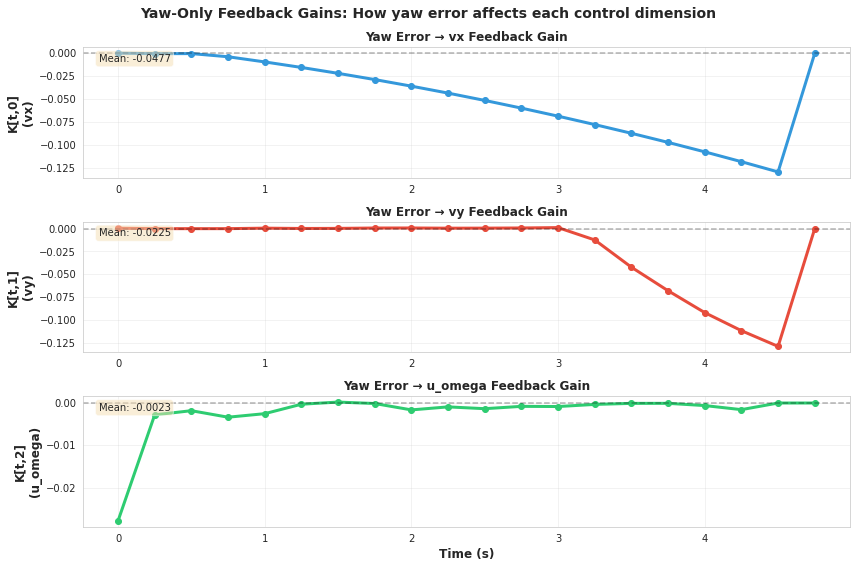


✓ Saved: go2_yaw_only_feedback_gains.pdf


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

control_labels = ['vx', 'vy', 'u_omega']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i in range(3):
    ax = axes[i]
    
    ax.plot(t, K_opt[:, i], '-', color=colors[i], linewidth=3, marker='o', markersize=6)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    ax.set_ylabel(f'K[t,{i}]\n({control_labels[i]})', fontweight='bold', fontsize=12)
    ax.set_title(f'Yaw Error → {control_labels[i]} Feedback Gain', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Annotation
    mean_val = np.mean(K_opt[:, i])
    ax.text(0.02, 0.95, f'Mean: {mean_val:.4f}',
           transform=ax.transAxes, fontsize=10,
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
           verticalalignment='top')

axes[-1].set_xlabel('Time (s)', fontweight='bold', fontsize=12)

plt.suptitle('Yaw-Only Feedback Gains: How yaw error affects each control dimension',
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('go2_yaw_only_feedback_gains.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: go2_yaw_only_feedback_gains.pdf")

## 7. Visualize Final Reachable Sets

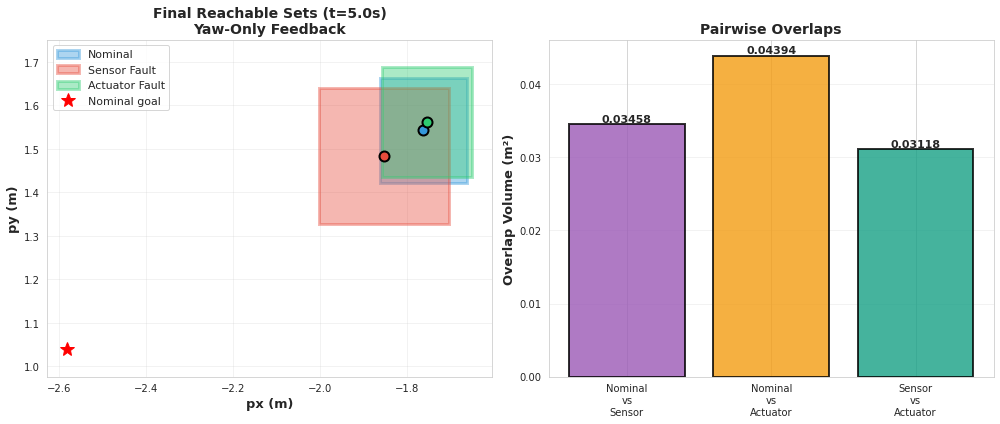


✓ Saved: go2_yaw_only_reachable_sets.pdf


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {'Nominal': '#3498db', 'Sensor Fault': '#e74c3c', 'Actuator Fault': '#2ecc71'}

# Left: Final position intervals
ax = axes[0]

for scenario_name, pos_int in stats['position_intervals'].items():
    px_l, px_u = float(pos_int.lower[0]), float(pos_int.upper[0])
    py_l, py_u = float(pos_int.lower[1]), float(pos_int.upper[1])
    
    rect = Rectangle(
        (px_l, py_l),
        px_u - px_l,
        py_u - py_l,
        linewidth=3,
        edgecolor=colors[scenario_name],
        facecolor=colors[scenario_name],
        alpha=0.4,
        label=scenario_name
    )
    ax.add_patch(rect)
    
    # Center point
    cx, cy = (px_l + px_u)/2, (py_l + py_u)/2
    ax.plot(cx, cy, 'o', color=colors[scenario_name],
           markersize=10, markeredgecolor='black', markeredgewidth=2, zorder=10)

# Nominal goal
ax.plot(px_nom[-1], py_nom[-1], 'r*', markersize=15, label='Nominal goal', zorder=15)

ax.set_xlabel('px (m)', fontsize=13, fontweight='bold')
ax.set_ylabel('py (m)', fontsize=13, fontweight='bold')
ax.set_title(f'Final Reachable Sets (t={N*dt}s)\nYaw-Only Feedback',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axis('equal')

# Right: Overlap bar chart
ax = axes[1]

overlap_labels = list(stats['overlaps'].keys())
overlap_values = list(stats['overlaps'].values())

short_labels = [
    label.replace(' vs ', '\nvs\n').replace(' Fault', '')
    for label in overlap_labels
]

bars = ax.bar(range(len(overlap_values)), overlap_values,
             color=['#9b59b6', '#f39c12', '#16a085'],
             alpha=0.8, edgecolor='black', linewidth=2)

ax.set_xticks(range(len(overlap_labels)))
ax.set_xticklabels(short_labels, fontsize=10)
ax.set_ylabel('Overlap Volume (m²)', fontsize=13, fontweight='bold')
ax.set_title('Pairwise Overlaps', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Value labels
for bar, val in zip(bars, overlap_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{val:.5f}',
           ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('go2_yaw_only_reachable_sets.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: go2_yaw_only_reachable_sets.pdf")

## 8. Compare: Zero Feedback vs Optimized Feedback

In [9]:
# Baseline: zero feedback (pure feedforward)
K_zero = np.zeros_like(K_opt)
stats_zero = optimizer.evaluate(K_zero)

print("\n" + "="*70)
print("COMPARISON: Zero Feedback vs Optimized Yaw Feedback")
print("="*70)

print(f"\n{'Metric':<40} {'Zero K':>15} {'Optimized K':>15} {'Improvement':>15}")
print("-"*85)

print(f"{'Total overlap (m²)':<40} {stats_zero['total_overlap']:>15.6f} {stats['total_overlap']:>15.6f}", end="")
improvement_overlap = (stats_zero['total_overlap'] - stats['total_overlap']) / stats_zero['total_overlap'] * 100
print(f" {improvement_overlap:>14.2f}%")

print(f"{'Tracking error (||K||)':<40} {stats_zero['tracking_error']:>15.6f} {stats['tracking_error']:>15.6f}  {'N/A':>15}")

print("\nPairwise overlaps:")
for key in stats['overlaps'].keys():
    zero_val = stats_zero['overlaps'][key]
    opt_val = stats['overlaps'][key]
    improvement = (zero_val - opt_val) / zero_val * 100 if zero_val > 0 else 0
    print(f"  {key:<38} {zero_val:>15.6f} {opt_val:>15.6f} {improvement:>14.2f}%")

if stats['total_overlap'] < stats_zero['total_overlap']:
    print("\n✓ Yaw-only feedback achieves better separation!")
else:
    print("\n⚠️ Zero feedback performs better (feedback may be counterproductive)")

print("\nNote: Yaw-only feedback is much more challenging than full state feedback!")


COMPARISON: Zero Feedback vs Optimized Yaw Feedback

Metric                                            Zero K     Optimized K     Improvement
-------------------------------------------------------------------------------------
Total overlap (m²)                              0.188194        0.109699          41.71%
Tracking error (||K||)                          0.000000        0.354312              N/A

Pairwise overlaps:
  Nominal vs Sensor Fault                       0.062731        0.034584          44.87%
  Nominal vs Actuator Fault                     0.062731        0.043936          29.96%
  Sensor Fault vs Actuator Fault                0.062731        0.031179          50.30%

✓ Yaw-only feedback achieves better separation!

Note: Yaw-only feedback is much more challenging than full state feedback!


## 9. Interpretation and Key Insights

### Yaw-Only Feedback vs Full State Feedback

| Aspect | Full State (px, py, yaw) | Yaw-Only |
|--------|-------------------------|----------|
| **Information** | Complete position + heading | Heading only |
| **Observability** | Full state observable | Position hidden |
| **Control authority** | Direct position correction | Indirect via yaw |
| **Difficulty** | Easier | Much harder |
| **Realism** | Requires GPS | IMU-only (more realistic) |

### Why Yaw-Only is Harder

1. **No direct position feedback**: Can't correct px, py errors directly
2. **Must infer position from yaw**: Requires integrating heading to estimate position
3. **Sensor faults affect observations**: Gyro faults corrupt the yaw measurement
4. **Accumulating errors**: Position errors compound without correction

### Feedback Gain Interpretation

The optimized gains `K[t] = [K_vx, K_vy, K_omega]` tell us:

```
If yaw error = +1 rad (robot facing ~57° to the right):
  → Adjust vx by K_vx
  → Adjust vy by K_vy  
  → Adjust angular acceleration by K_omega
```

**Typical patterns**:
- **K_omega ≠ 0**: Corrects heading errors (direct effect)
- **K_vx, K_vy ≠ 0**: Adjusts velocity to compensate for position drift (indirect)

### Fault Distinguishability with Yaw-Only Feedback

**Actuator Fault**:
- Affects angular acceleration → changes yaw trajectory
- Also affects position (reduced turning creates wider arcs)
- Somewhat detectable via yaw deviations

**Sensor Fault** (Gyro):
- Directly corrupts yaw observation!
- Makes fault diagnosis MUCH harder
- The controller sees wrong yaw and makes wrong corrections
- Can create feedback instability

### Practical Implications

1. **IMU-only navigation is challenging** for fault diagnosis
2. **Sensor faults can masquerade as actuator faults** (and vice versa)
3. **Need complementary sensors** (GPS, vision) for robust diagnosis
4. **Temporal patterns help**: Sensor faults accumulate differently than actuator faults

### Comparison with Position Feedback

Expected performance differences:
- **Overlap**: Yaw-only will have MORE overlap (less separation)
- **Position intervals**: Yaw-only will have WIDER intervals (more uncertainty)
- **Optimization difficulty**: Yaw-only is HARDER (60 parameters vs 180+ for full state)

### Design Recommendations

For yaw-only feedback systems:
1. **Use temporal filtering**: Track yaw error trends over time
2. **Integrate complementary sensors**: Fuse IMU with GPS/vision
3. **Model gyro bias explicitly**: Estimate and compensate for drift
4. **Conservative gains**: Avoid aggressive feedback that amplifies noise
5. **Fault isolation logic**: Combine position (when available) and yaw information